## Encontro 1 - Baselines

## Importar e organizar os dados


In [7]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../dados/mecaniqa_dataset.csv")
df.columns = df.columns.str.strip()
df["Data"] = pd.to_datetime(df["Data"])
df = df.set_index("Data").sort_index().asfreq("D")

colunas = ["Trocas_Oleo", "Manutencao_Motor"]
df = df[colunas]
df.head()

,Trocas_Oleo,Manutencao_Motor
Data,,
2024-01-01,11.0,2.0
2024-01-02,9.0,4.0
2024-01-03,12.0,1.0
2024-01-04,15.0,8.0
2024-01-05,25.0,10.0


## Tratar os dados


In [8]:
df["Trocas_Oleo"] = df["Trocas_Oleo"].clip(upper=55)
df["Manutencao_Motor"] = df["Manutencao_Motor"].clip(lower=0, upper=26)

# Guarda os valores observados, inclusive os que estão ausentes.
observado = df.copy()

# Preenche o histórico usando somente valores anteriores.
df = df.ffill()
df.isna().sum()

Trocas_Oleo         0
Manutencao_Motor    0
dtype: int64

## Criar os baselines


In [9]:
def modelo_naive(serie):
    return serie.shift(1)

def modelo_media_movel(serie, janela):
    return serie.shift(1).rolling(janela).mean()

previsoes = {}

for coluna in colunas:
    previsoes[coluna] = pd.DataFrame({
        "Real": observado[coluna],
        "Naive": modelo_naive(df[coluna]),
        "Media_7": modelo_media_movel(df[coluna], 7),
        "Media_30": modelo_media_movel(df[coluna], 30)
    })

## Comparar as previsões nos gráficos


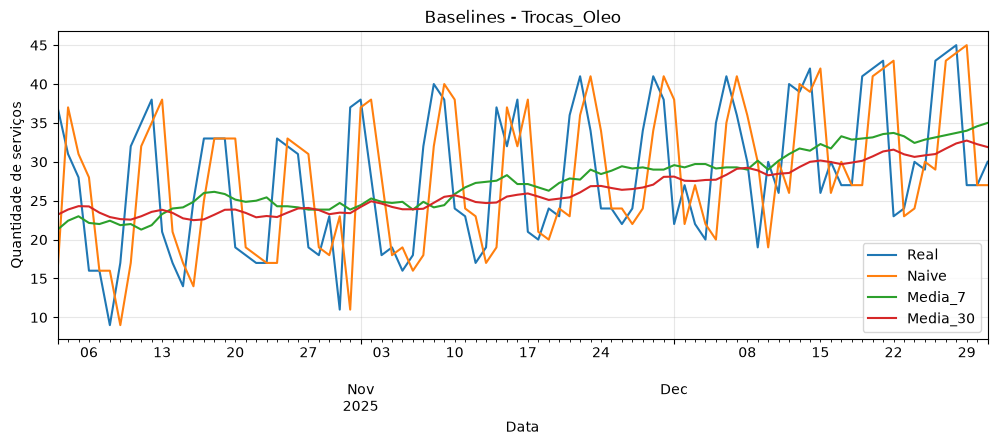

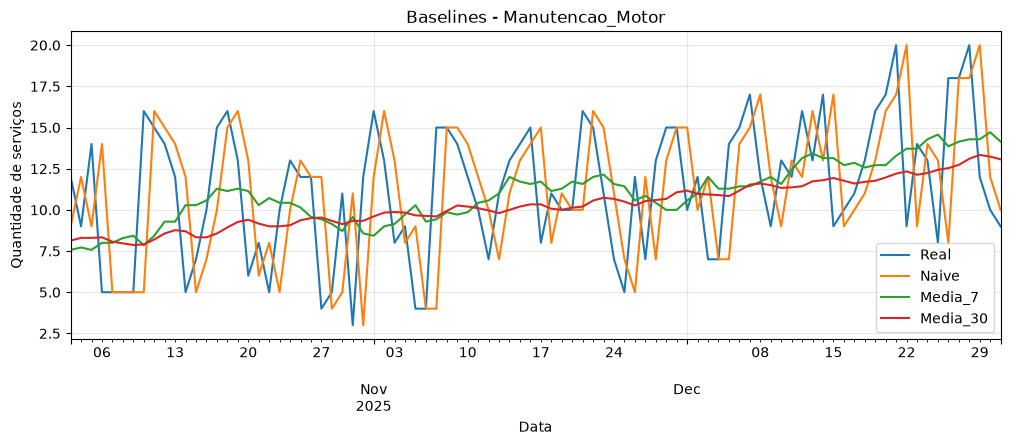

In [10]:
for coluna in colunas:
    previsoes[coluna].tail(90).plot(figsize=(12, 4))
    plt.title(f"Baselines - {coluna}")
    plt.xlabel("Data")
    plt.ylabel("Quantidade de serviços")
    plt.grid(alpha=0.3)
    plt.show()

## Médias descritivas e decomposição semanal


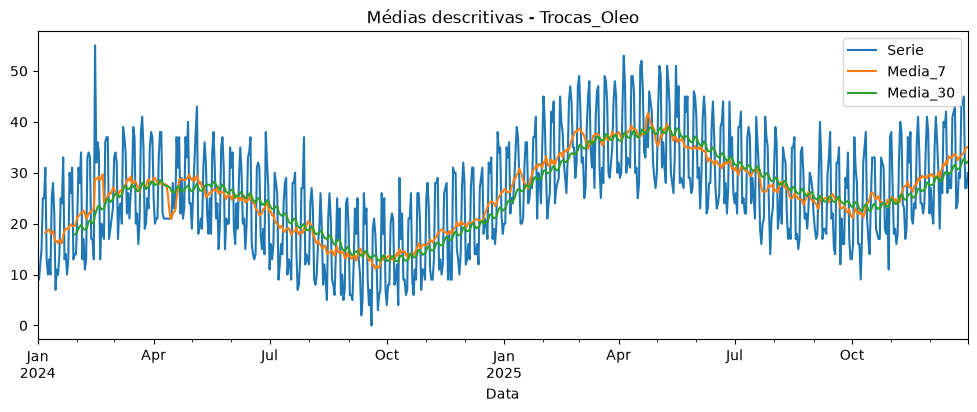

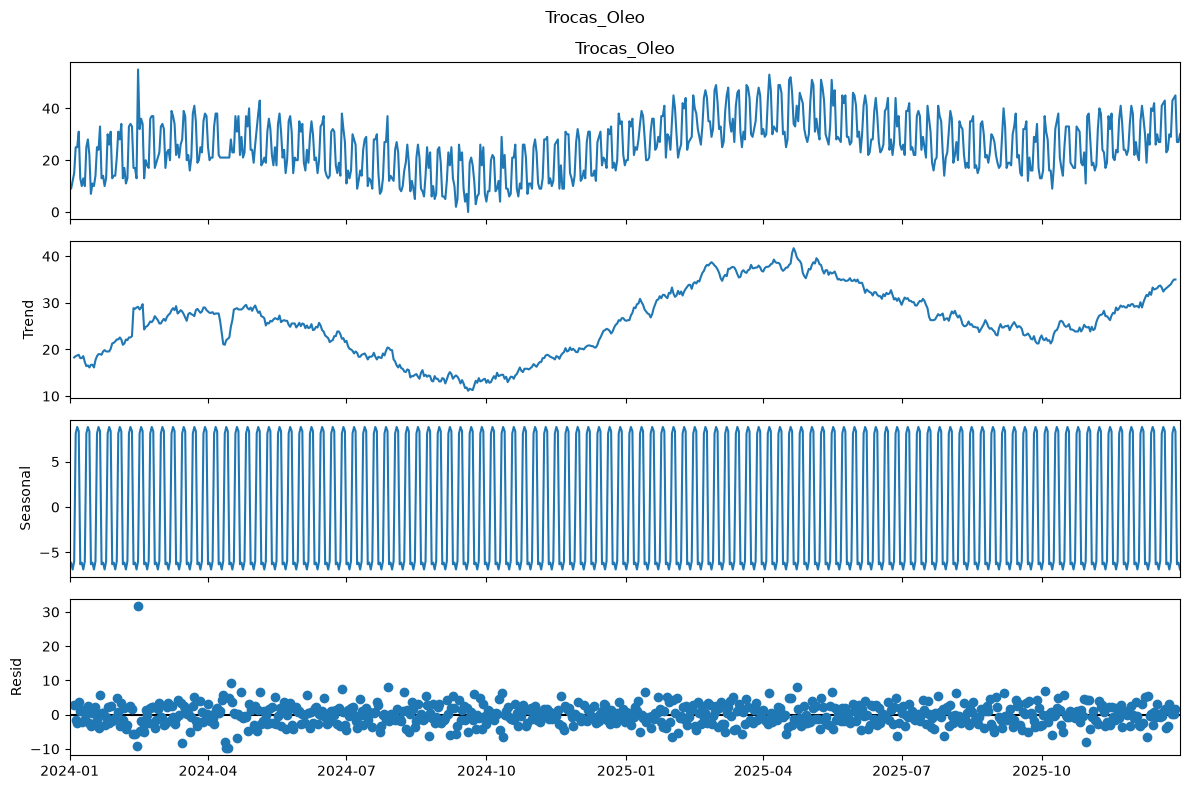

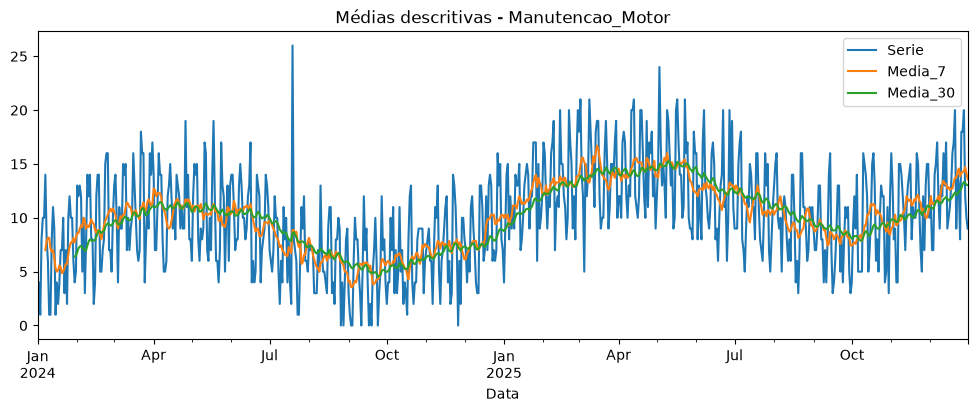

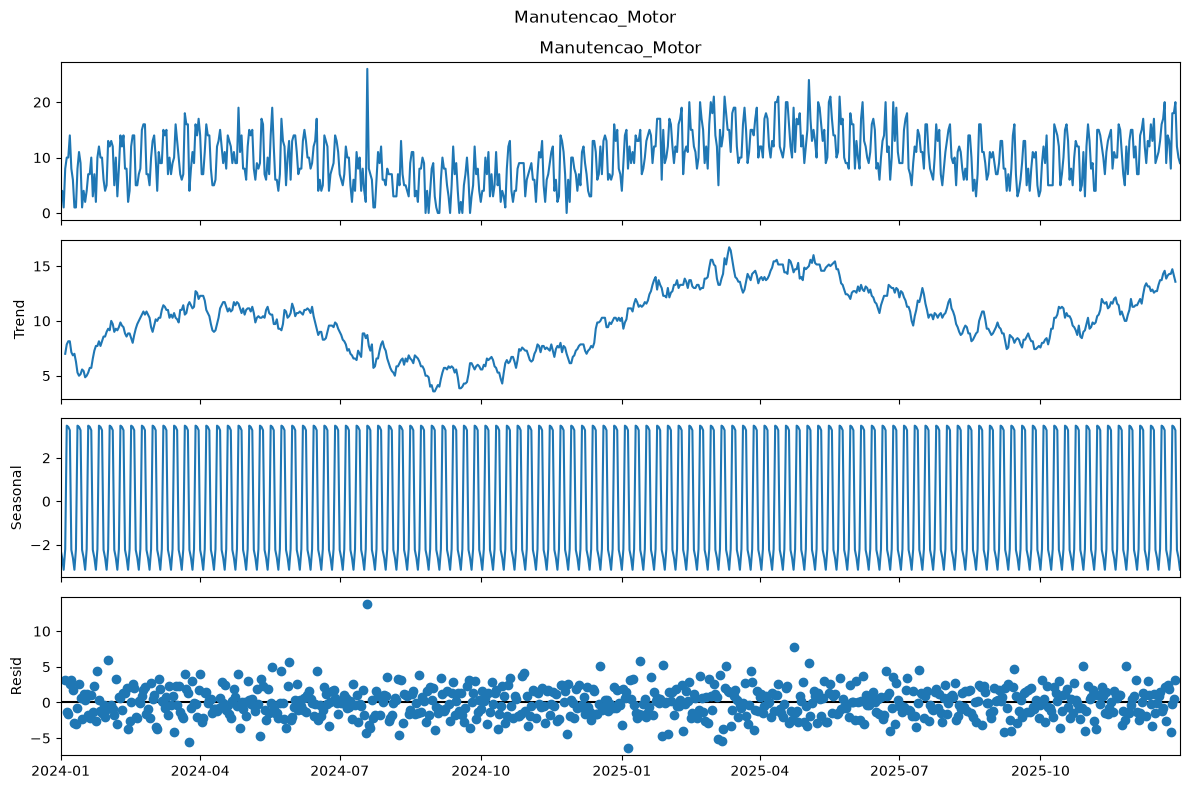

In [11]:
from statsmodels.tsa.seasonal import seasonal_decompose

for coluna in colunas:
    medias = pd.DataFrame({
        "Serie": df[coluna],
        "Media_7": df[coluna].rolling(7).mean(),
        "Media_30": df[coluna].rolling(30).mean()
    })
    medias.plot(figsize=(12, 4), title=f"Médias descritivas - {coluna}")
    plt.show()

    resultado = seasonal_decompose(df[coluna], model="additive", period=7)
    figura = resultado.plot()
    figura.set_size_inches(12, 8)
    figura.suptitle(coluna)
    figura.tight_layout()
    plt.show()